<a href="https://colab.research.google.com/github/manaswinidoma/data-driven-persona-development/blob/main/Final_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
class WVSPersonaBuilder:
    """
    Build personas from WVS survey data using metadata-informed clustering
    """

    def __init__(self, data_file, metadata_file):
        self.data_file = data_file
        self.metadata_file = metadata_file

        self.raw_data = None
        self.metadata = None
        self.augmented_metadata = None
        self.column_mapping = {}
        self.variable_info = {}
        self.processed_data = None
        self.imputed_data = None
        self.cluster_labels = None
        self.error_codes = {}

    def load_and_map_data(self):
        """
        Load data and create mapping between column names and question numbers
        """
        print("="*70)
        print("LOADING AND MAPPING DATA")
        print("="*70)

        # Load survey responses
        self.raw_data = pd.read_excel(self.data_file, sheet_name='Data')
        print(f"\n✓ Loaded survey responses: {len(self.raw_data)} respondents")
        print(f"✓ Original columns: {len(self.raw_data.columns)}")

        # Load metadata
        self.metadata = pd.read_excel(self.metadata_file, sheet_name='Metadata')
        print(f"✓ Loaded metadata: {len(self.metadata)} entries")

        # Load augmented metadata (REQUIRED)
        try:
            self.augmented_metadata = pd.read_excel(
                'WVS_Metadata_Augmented.xlsx',
                sheet_name='Metadata_Augmented'
            )
            print(f"✓ Loaded augmented metadata with variable classifications")
            self.metadata = self.augmented_metadata
        except FileNotFoundError:
            print("\n" + "="*70)
            print("ERROR: WVS_Metadata_Augmented.xlsx NOT FOUND")
            print("="*70)
            print("\nYou must run the metadata augmentation script first:")
            print("1. Run Metadata_Augmentation.ipynb")
            print("2. This creates WVS_Metadata_Augmented.xlsx")
            print("3. Then run this analysis script")
            print("\nWithout augmented metadata, variable types cannot be")
            print("determined correctly, leading to invalid clustering results.")
            raise SystemExit("Missing required file: WVS_Metadata_Augmented.xlsx")

        # Create column name to question number mapping
        print("\n--- Creating column mapping ---")

        # Get unique questions from metadata
        questions = self.metadata.groupby('Question_Number').first().reset_index()

        for _, row in questions.iterrows():
            q_num = row['Question_Number']
            q_text = row['Question_Text']

            # Try to find matching column in data
            # Match by checking if column name contains significant part of question text
            q_text_clean = q_text.lower()[:50]  # First 50 chars

            for col in self.raw_data.columns:
                col_clean = col.lower()
                # If column name is similar to question text
                if col_clean in q_text_clean or q_text_clean[:30] in col_clean:
                    self.column_mapping[col] = q_num
                    break

        print(f"✓ Mapped {len(self.column_mapping)} columns to question numbers")

        # Show some examples
        print("\nMapping examples:")
        for col, q_num in list(self.column_mapping.items())[:3]:
            print(f"  '{col[:40]}...' → {q_num}")

        return self

    def _auto_encode_with_missing_metadata(self, col, col_data, var_type='binary'):
        """
        Auto-detect and encode variables even if metadata is incomplete
        Handles multiple WVS patterns: binary, ordinal scales
        """
        unique_vals = col_data.dropna().unique()

        # Skip if too many unique values
        if len(unique_vals) > 10:
            return None

        # PATTERN 1: Binary (Important/Not mentioned, Yes/No, Active/Inactive member)
        if var_type == 'binary' or len(unique_vals) <= 3:
            positive_keywords = ['important', 'mentioned', 'yes', 'agree', 'active member', 'belong']
            negative_keywords = ['not mentioned', 'not important', 'no', 'disagree',
                                "don't belong", 'not a member', 'inactive member',
                                'do not belong', 'does not belong']

            binary_map = {}
            found_positive = False
            found_negative = False

            for val in unique_vals:
                val_str = str(val).lower()

                # Check for positive response
                if any(keyword in val_str for keyword in positive_keywords):
                    binary_map[val] = 1.0
                    found_positive = True
                # Check for negative response
                elif any(keyword in val_str for keyword in negative_keywords):
                    binary_map[val] = 0.0
                    found_negative = True
                # Check for error codes
                elif any(err in val_str for err in ['missing', 'no answer', "don't know", 'not asked']):
                    binary_map[val] = np.nan

            # Only use this mapping if we found both positive and negative
            if found_positive and found_negative:
                return col_data.map(binary_map)

        # PATTERN 2: Ordinal scales (Confidence, Frequency, Agreement, Membership)
        ordinal_patterns = [
            # Confidence scale
            ['none at all', 'not very much', 'quite a lot', 'a great deal'],
            ['not at all', 'not very much', 'quite a lot', 'a great deal'],
            # Frequency scale
            ['never', 'rarely', 'sometimes', 'often', 'very often', 'always'],
            ['never', 'seldom', 'sometimes', 'often', 'very often'],
            # Agreement scale
            ['strongly disagree', 'disagree', 'neither', 'agree', 'strongly agree'],
            ['completely disagree', 'disagree', 'neither', 'agree', 'completely agree'],
            # Membership scale
            ['not a member', "don't belong", 'inactive member', 'active member'],
            ['do not belong', 'inactive member', 'active member'],
        ]

        for pattern in ordinal_patterns:
            ordinal_map = {}
            matched_count = 0

            for val in unique_vals:
                val_str = str(val).lower().strip()

                # Skip and mark error codes as NaN
                if any(err in val_str for err in ['missing', 'no answer', "don't know", 'not asked']):
                    ordinal_map[val] = np.nan
                    continue

                # Try to match to pattern
                matched = False
                for i, pattern_word in enumerate(pattern):
                    if pattern_word in val_str:
                        ordinal_map[val] = float(i)
                        matched = True
                        matched_count += 1
                        break

                if not matched:
                    break  # This pattern doesn't work, try next one

            # If we matched at least 2 unique values with this pattern, use it
            if matched_count >= 2 and matched_count == len([v for v in unique_vals if not any(err in str(v).lower() for err in ['missing', 'no answer', "don't know", 'not asked'])]):
                return col_data.map(ordinal_map)

        return None

    def build_variable_index(self):
        """
        Build index of variable information from metadata
        """
        print("\n" + "="*70)
        print("BUILDING VARIABLE INDEX")
        print("="*70)

        # Extract error codes
        if 'Rating_Type' in self.metadata.columns:
            error_data = self.metadata[self.metadata['Rating_Type'] == 'missing']
            for _, row in error_data.iterrows():
                code = row['Rating_Code']
                if pd.notna(code):
                    self.error_codes[int(code)] = row['Rating_Label']

        print(f"\n✓ Identified {len(self.error_codes)} error codes")

        # Build variable info for each question
        questions = self.metadata['Question_Number'].unique()

        for question in questions:
            q_data = self.metadata[self.metadata['Question_Number'] == question]

            var_info = {
                'question_text': q_data.iloc[0]['Question_Text'],
                'n_categories': len(q_data[q_data['Rating_Type'] == 'valid']) if 'Rating_Type' in q_data.columns else 0,
            }

            # Add augmented metadata (must exist)
            if 'Variable_Type' in q_data.columns:
                var_info['variable_type'] = q_data.iloc[0]['Variable_Type']
                var_info['is_continuous'] = q_data.iloc[0]['Is_Continuous']
                var_info['is_ordinal'] = q_data.iloc[0]['Is_Ordinal']
                var_info['is_nominal'] = q_data.iloc[0]['Is_Nominal']
                var_info['is_binary'] = q_data.iloc[0]['Is_Binary']
                var_info['scale_direction'] = q_data.iloc[0]['Scale_Direction']
            else:
                raise ValueError(
                    f"Variable_Type column missing from metadata.\n"
                    f"Run Metadata_Augmentation.ipynb to create augmented metadata."
                )

            self.variable_info[question] = var_info

        print(f"✓ Indexed {len(self.variable_info)} variables")

        if 'Variable_Type' in self.metadata.columns:
            type_counts = pd.Series([v['variable_type'] for v in self.variable_info.values()]).value_counts()
            print("\nVariable type distribution:")
            for var_type, count in type_counts.items():
                print(f"  {var_type.capitalize():12s}: {count:4d}")

        return self

    def select_clustering_features(self):
        """
        Select features by removing contextual/technical variables
        Book principle: Use individual-level data only, grouped by themes
        """
        print("\n" + "="*70)
        print("SELECTING FEATURES FOR CLUSTERING")
        print("="*70)

        # REMOVE: Technical/Administrative variables (not respondent characteristics)
        technical_patterns = [
            'A_YEAR', 'B_COUNTRY', 'C_COW', 'J_INTDATE', 'FW_', 'K_TIME',
            'K_DURATION', 'Q_MODE', 'N_REGION', 'G_TOWNSIZE', 'H_SETTLEMENT',
            'H_URBRURAL', 'I_PSU', 'S017', 'S018', 'S019', 'S020', 'S021',
            'S022', 'S023', 'S024', 'S025', 'S026', 'S027', 'S028'
        ]

        # REMOVE: Contextual/Country-level variables (not individual responses)
        contextual_patterns = [
            'v2x_', 'v2el', 'v2xcl', 'v2xeg', 'v2ex', 'v2ju', 'v2cl', 'v2cs',
            'v2me', 'v2pe', 'v2ca', 'td_', 'bti', 'fh_', 'regionWB', 'incomeWB',
            'popWB', 'GDPWB', 'landWB', 'giniWB', 'lifeWB', 'unemployWB',
            'healthWB', 'educationWB', 'democ', 'autoc', 'polity', 'durable',
            'xrreg', 'xrcomp', 'xropen', 'xconst', 'parreg', 'parcomp',
            'ID_GPS', 'ID_PartyFacts', 'Partyname', 'Partyabb', 'CPARTY',
            'Type_Values', 'Type_Populism', 'Type_Populist', 'Type_Partysize',
            'GPS_V', 'WVS_LR_Party', 'WVS_LibCon_Party', 'WVS_Polmistrust'
        ]

        # REMOVE: WVS composite indexes (avoid double-counting, they're made from raw questions)
        index_patterns = [
            'Y001', 'Y002', 'Y003',  # Cultural dimensions
            'SACSECVAL', 'RESEMAVAL',  # Secular/traditional values
            'SECVALWGT', 'RESEMAVALWGT',  # Weights
            'I_WOMPOL', 'I_WOMEDU', 'I_WOMJOB',  # Intermediate calculations
            'DEFIANCE', 'SCEPTICISM', 'RELATIVISM', 'DISBELIEF',
            'AUTONOMY', 'EQUALITY', 'CHOICE', 'VOICE'
        ]

        # Combine all exclusion patterns
        exclude_all = technical_patterns + contextual_patterns + index_patterns

        # Filter columns: Keep if it's NOT in exclusion list
        feature_cols = []

        for col in self.raw_data.columns:
            # Check if column matches any exclusion pattern
            should_exclude = False

            for pattern in exclude_all:
                if pattern in col:
                    should_exclude = True
                    break

            if not should_exclude:
                feature_cols.append(col)

        print(f"\n✓ Variable selection results:")
        print(f"  - Original columns: {len(self.raw_data.columns)}")
        print(f"  - Removed (technical): ~{len([c for c in self.raw_data.columns if any(p in c for p in technical_patterns)])}")
        print(f"  - Removed (contextual): ~{len([c for c in self.raw_data.columns if any(p in c for p in contextual_patterns)])}")
        print(f"  - Removed (indexes): ~{len([c for c in self.raw_data.columns if any(p in c for p in index_patterns)])}")
        print(f"  - KEPT for clustering: {len(feature_cols)}")

        print(f"\n✓ Book compliance: Using individual-level survey responses only")

        # Store for later use
        self.feature_columns = feature_cols

        # Optional: Group by WVS themes for interpretability
        self._create_theme_groups()

        return self


    def _create_theme_groups(self):
        """
        Group variables into WVS official themes for persona profiling
        """
        # WVS official thematic structure (from Variables.pdf)
        # This is for INTERPRETATION later, not for filtering

        self.theme_groups = {
            'demographics': [],
            'social_values': [],
            'happiness_wellbeing': [],
            'social_capital_trust': [],
            'economic_values': [],
            'corruption_perceptions': [],
            'migration_perceptions': [],
            'security_concerns': [],
            'postmaterialism': [],
            'science_technology': [],
            'religious_values': [],
            'ethical_values': [],
            'political_interest': [],
            'political_culture': []
        }

        # Categorize features into themes based on column names
        for col in self.feature_columns:
            col_lower = col.lower()

            if any(x in col_lower for x in ['age', 'sex', 'gender', 'born', 'education', 'employment',
                                            'occupation', 'income', 'marital', 'children', 'immigrant',
                                            'citizen', 'ethnic', 'language', 'religion denomination']):
                self.theme_groups['demographics'].append(col)

            elif any(x in col_lower for x in ['important in life', 'important child', 'neighbors:']):
                self.theme_groups['social_values'].append(col)

            elif any(x in col_lower for x in ['happiness', 'health', 'freedom of choice', 'satisfaction']):
                self.theme_groups['happiness_wellbeing'].append(col)

            elif any(x in col_lower for x in ['trust', 'membership', 'active/inactive']):
                self.theme_groups['social_capital_trust'].append(col)

            elif any(x in col_lower for x in ['income equality', 'private vs', 'competition',
                                              'hard work', 'environment vs']):
                self.theme_groups['economic_values'].append(col)

            elif any(x in col_lower for x in ['bribe', 'corruption']):
                self.theme_groups['corruption_perceptions'].append(col)

            elif any(x in col_lower for x in ['immigrant policy', 'impact of immigrants']):
                self.theme_groups['migration_perceptions'].append(col)

            elif any(x in col_lower for x in ['worries', 'victim of crime', 'war involving',
                                              'terrorist', 'fight for country']):
                self.theme_groups['security_concerns'].append(col)

            elif any(x in col_lower for x in ['aims of country', 'aims of respondent']):
                self.theme_groups['postmaterialism'].append(col)

            elif any(x in col_lower for x in ['science', 'technology']):
                self.theme_groups['science_technology'].append(col)

            elif any(x in col_lower for x in ['importance of god', 'believe in', 'religious services',
                                              'pray', 'religious person']):
                self.theme_groups['religious_values'].append(col)

            elif any(x in col_lower for x in ['justifiable', 'homosexuality', 'abortion',
                                              'divorce', 'euthanasia', 'suicide']):
                self.theme_groups['ethical_values'].append(col)

            elif any(x in col_lower for x in ['interest in politics', 'petition', 'boycott',
                                              'demonstration', 'vote']):
                self.theme_groups['political_interest'].append(col)

            elif any(x in col_lower for x in ['confidence:', 'political system', 'democracy',
                                              'strong leader', 'army rule']):
                self.theme_groups['political_culture'].append(col)

        print(f"\n✓ Grouped into {len(self.theme_groups)} WVS themes:")
        for theme, cols in self.theme_groups.items():
            if len(cols) > 0:
                print(f"  - {theme:25s}: {len(cols):3d} variables")

        print(f"\n  (Themes used for persona interpretation, not filtering)")

    def prepare_for_clustering(self):
        """
        Encode variables based on their type from augmented metadata
        Book principle: Different variable types need different preprocessing
        """
        print("\n" + "="*70)
        print("PREPARING DATA FOR CLUSTERING")
        print("="*70)

        data = self.raw_data[self.feature_columns].copy()

        # Replace error codes with NaN
        print("\n--- Cleaning error codes ---")
        for error_code in self.error_codes.keys():
            data.replace(error_code, np.nan, inplace=True)

        error_cleaned = data.isnull().sum().sum()
        print(f"✓ Replaced {error_cleaned} error code values with NaN")

        # Now encode based on variable type
        print("\n--- Encoding variables by type ---")

        encoded_data = {}  # Use dict instead of DataFrame initially

        continuous_cols = []
        ordinal_cols = []
        nominal_cols = []
        binary_cols = []
        unknown_cols = []

        for col in self.feature_columns:
            col_data = data[col].copy()

            # Find this column's question number and get metadata
            q_num = None
            for mapped_col, mapped_q in self.column_mapping.items():
                if mapped_col == col:
                    q_num = mapped_q
                    break

            # Try to convert to numeric first (handles most cases)
            numeric_attempt = pd.to_numeric(col_data, errors='coerce')
            mostly_numeric = numeric_attempt.notna().sum() > len(col_data) * 0.5

            # Get variable info from metadata
            if q_num and q_num in self.variable_info:
                var_info = self.variable_info[q_num]

                # CONTINUOUS variables (Age, Year of birth)
                if var_info.get('is_continuous', False):
                    continuous_cols.append(col)
                    encoded_data[col] = numeric_attempt

                # BINARY variables
                elif var_info.get('is_binary', False):
                    binary_cols.append(col)
                    if mostly_numeric:
                        encoded_data[col] = numeric_attempt
                    else:
                        # Try auto-detection first (handles incomplete metadata)
                        auto_encoded = self._auto_encode_with_missing_metadata(col, col_data, var_type='binary')

                        if auto_encoded is not None:
                            encoded_data[col] = auto_encoded
                            print(f"  ✓ Auto-encoded binary: {col[:50]}")
                        else:
                            # Fall back to simple label encoding
                            unique_vals = col_data.dropna().unique()
                            if len(unique_vals) <= 2 and len(unique_vals) > 0:
                                mapping = {unique_vals[i]: float(i) for i in range(len(unique_vals))}
                                encoded_data[col] = col_data.map(mapping)
                            else:
                                encoded_data[col] = numeric_attempt

                # ORDINAL variables
                elif var_info.get('is_ordinal', False):
                    ordinal_cols.append(col)
                    if mostly_numeric:
                        # Already numeric, check scale direction
                        scale_dir = var_info.get('scale_direction', 'ascending')
                        if scale_dir == 'descending' and numeric_attempt.notna().sum() > 0:
                            # Reverse scale
                            max_val = numeric_attempt.max()
                            min_val = numeric_attempt.min()
                            encoded_data[col] = max_val + min_val - numeric_attempt
                        else:
                            encoded_data[col] = numeric_attempt
                    else:
                        # Try auto-detection first
                        auto_encoded = self._auto_encode_with_missing_metadata(col, col_data, var_type='ordinal')

                        if auto_encoded is not None:
                            encoded_data[col] = auto_encoded
                            print(f"  ✓ Auto-encoded ordinal: {col[:50]}")
                        else:
                            # Fall back to existing encoding
                            try:
                                unique_vals = sorted([str(x) for x in col_data.dropna().unique()])
                                scale_dir = var_info.get('scale_direction', 'ascending')

                                if scale_dir == 'descending':
                                    mapping = {unique_vals[i]: float(len(unique_vals) - 1 - i) for i in range(len(unique_vals))}
                                else:
                                    mapping = {unique_vals[i]: float(i) for i in range(len(unique_vals))}

                                col_str = col_data.astype(str)
                                mapped_values = col_str.map(mapping)
                                encoded_data[col] = pd.to_numeric(mapped_values, errors='coerce')
                            except:
                                encoded_data[col] = numeric_attempt

                # NOMINAL variables
                elif var_info.get('is_nominal', False):
                    nominal_cols.append(col)
                    if mostly_numeric:
                        encoded_data[col] = numeric_attempt
                    else:
                        # Label encode
                        try:
                            unique_vals = [str(x) for x in col_data.dropna().unique() if str(x) != 'nan']
                            if len(unique_vals) > 0:
                                mapping = {unique_vals[i]: float(i) for i in range(len(unique_vals))}
                                col_str = col_data.astype(str)
                                mapped_values = col_str.map(mapping)
                                encoded_data[col] = pd.to_numeric(mapped_values, errors='coerce')
                            else:
                                encoded_data[col] = numeric_attempt
                        except:
                            encoded_data[col] = numeric_attempt

                # Unknown type (no classification in metadata)
                else:
                    unknown_cols.append(col)

                    # Try automatic detection
                    auto_encoded = self._auto_encode_with_missing_metadata(col, col_data, var_type='binary')

                    if auto_encoded is not None:
                        encoded_data[col] = auto_encoded
                        binary_cols.append(col)
                        print(f"  ✓ Auto-detected binary: {col[:50]}")
                    else:
                        # Fall back to numeric conversion
                        encoded_data[col] = numeric_attempt

            else:
                # No metadata found
                unknown_cols.append(col)
                encoded_data[col] = numeric_attempt

        # Convert dict to DataFrame
        encoded_df = pd.DataFrame(encoded_data, index=data.index)

        print(f"\n✓ Encoding summary:")
        print(f"  - Continuous: {len(continuous_cols)}")
        print(f"  - Binary: {len(binary_cols)}")
        print(f"  - Ordinal: {len(ordinal_cols)}")
        print(f"  - Nominal: {len(nominal_cols)}")
        print(f"  - Unknown type: {len(unknown_cols)}")
        print(f"  - Successfully encoded: {len(encoded_df.columns)} / {len(self.feature_columns)}")

        if len(encoded_df.columns) < len(self.feature_columns):
            print(f"\n⚠ WARNING: {len(self.feature_columns) - len(encoded_df.columns)} columns failed encoding (dropped)")

        # CRITICAL: Force ALL columns to numeric - this is the final safety net
        print(f"\n--- Ensuring all data is numeric ---")

        non_numeric_cols = []
        for col in encoded_df.columns:
            # Check if column is numeric
            if not pd.api.types.is_numeric_dtype(encoded_df[col]):
                non_numeric_cols.append(col)
                # Force convert
                encoded_df[col] = pd.to_numeric(encoded_df[col], errors='coerce')

        if len(non_numeric_cols) > 0:
            print(f"⚠ Forced {len(non_numeric_cols)} non-numeric columns to numeric (converted strings to NaN)")

        # Double check - verify all columns are now numeric
        still_non_numeric = []
        for col in encoded_df.columns:
            if not pd.api.types.is_numeric_dtype(encoded_df[col]):
                still_non_numeric.append(col)

        if len(still_non_numeric) > 0:
            print(f"\n⚠⚠ CRITICAL: {len(still_non_numeric)} columns still non-numeric, dropping them:")
            for col in still_non_numeric:
                print(f"  - {col}")
            encoded_df = encoded_df.drop(columns=still_non_numeric)

        print(f"✓ All {len(encoded_df.columns)} columns are now guaranteed numeric")

        # Standardize ONLY continuous variables that exist
        continuous_cols_existing = [c for c in continuous_cols if c in encoded_df.columns]
        if len(continuous_cols_existing) > 0:
            print(f"\n--- Standardizing continuous variables ---")

            # Ensure continuous columns are actually numeric
            for col in continuous_cols_existing:
                encoded_df[col] = pd.to_numeric(encoded_df[col], errors='coerce')

            scaler = StandardScaler()

            # Fill NaN with 0 (simpler)
            continuous_data = encoded_df[continuous_cols_existing].copy()
            continuous_data = continuous_data.fillna(0)

            # Now standardize
            encoded_df[continuous_cols_existing] = scaler.fit_transform(continuous_data)
            print(f"✓ Standardized {len(continuous_cols_existing)} continuous variables (z-score)")

        self.processed_data = encoded_df

        print(f"\n✓ Processed data shape: {self.processed_data.shape}")
        print(f"✓ Ready for imputation")

        return self

    def find_optimal_clusters(self, min_k=3, max_k=7):
        """
        Find optimal number of clusters using multiple metrics
        Book principle: Personas typically range from 3-9, with 5-7 most common
        """
        print("\n" + "="*70)
        print("FINDING OPTIMAL NUMBER OF CLUSTERS")
        print("="*70)

        print(f"\n✓ Testing k={min_k} to k={max_k} clusters")
        print(f"  (Target: 3-5 personas as specified)")

        # Scale data for clustering
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(self.imputed_data)

        # Store metrics for each k
        metrics = {
            'k': [],
            'silhouette': [],
            'davies_bouldin': [],
            'calinski_harabasz': [],
            'inertia': []
        }

        print("\n--- Evaluating different k values ---")

        for k in range(min_k, max_k + 1):
            # Fit K-means
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
            labels = kmeans.fit_predict(scaled_data)

            # Calculate metrics
            sil_score = silhouette_score(scaled_data, labels)
            db_score = davies_bouldin_score(scaled_data, labels)
            ch_score = calinski_harabasz_score(scaled_data, labels)
            inertia = kmeans.inertia_

            metrics['k'].append(k)
            metrics['silhouette'].append(sil_score)
            metrics['davies_bouldin'].append(db_score)
            metrics['calinski_harabasz'].append(ch_score)
            metrics['inertia'].append(inertia)

            print(f"\nk={k}:")
            print(f"  Silhouette (higher=better):    {sil_score:.4f}")
            print(f"  Davies-Bouldin (lower=better): {db_score:.4f}")
            print(f"  Calinski-Harabasz (higher):    {ch_score:.2f}")
            print(f"  Inertia:                       {inertia:.2f}")

        # Determine optimal k using Silhouette score (most interpretable)
        best_idx = np.argmax(metrics['silhouette'])
        optimal_k = metrics['k'][best_idx]

        print("\n" + "="*70)
        print(f"✓ RECOMMENDED: k={optimal_k} clusters")
        print(f"  (Highest silhouette score: {metrics['silhouette'][best_idx]:.4f})")
        print("="*70)

        # Visualize metrics
        self._plot_clustering_metrics(metrics, optimal_k)

        return optimal_k

    def impute_missing(self, strategy='knn', n_neighbors=5):
        """
        Impute missing values with transparency reporting
        Book principle: Must be transparent about data quality (ASUBE model)
        """
        print("\n" + "="*70)
        print("IMPUTING MISSING VALUES")
        print("="*70)

        # Report missing data BEFORE imputation (Book: transparency requirement)
        print("\n--- Missing Data Assessment ---")

        missing_summary = []
        for col in self.processed_data.columns:
            total = len(self.processed_data)
            missing = self.processed_data[col].isnull().sum()
            missing_pct = (missing / total) * 100

            missing_summary.append({
                'variable': col,
                'missing_count': missing,
                'missing_pct': missing_pct
            })

        missing_df = pd.DataFrame(missing_summary)

        # Overall statistics
        total_values = self.processed_data.size
        total_missing = self.processed_data.isnull().sum().sum()
        overall_missing_pct = (total_missing / total_values) * 100

        print(f"\n✓ Overall missing data: {total_missing:,} values ({overall_missing_pct:.2f}%)")
        print(f"✓ Variables: {len(self.processed_data.columns)}")
        print(f"✓ Respondents: {len(self.processed_data)}")

        # Show variables with high missingness
        high_missing = missing_df[missing_df['missing_pct'] > 30].sort_values('missing_pct', ascending=False)

        if len(high_missing) > 0:
            print(f"\n⚠ WARNING: {len(high_missing)} variables have >30% missing data:")
            for idx, row in high_missing.head(10).iterrows():
                print(f"  - {row['variable'][:50]:50s}: {row['missing_pct']:5.1f}% missing")
            if len(high_missing) > 10:
                print(f"  ... and {len(high_missing) - 10} more")

        # Remove columns with 100% missing (KNN can't handle these)
        cols_all_missing = self.processed_data.columns[self.processed_data.isnull().all()].tolist()
        if len(cols_all_missing) > 0:
            print(f"\n⚠ Dropping {len(cols_all_missing)} columns with 100% missing data")
            self.processed_data = self.processed_data.drop(columns=cols_all_missing)

        # Perform imputation
        print(f"\n--- Imputing using {strategy.upper()} strategy ---")

        if strategy == 'knn':
            imputer = KNNImputer(n_neighbors=n_neighbors, keep_empty_features=True)
            print(f"✓ Using KNN imputation (k={n_neighbors} neighbors)")
            print(f"  (Fills missing values using {n_neighbors} most similar respondents)")

            imputed_array = imputer.fit_transform(self.processed_data)
            self.imputed_data = pd.DataFrame(
                imputed_array,
                columns=self.processed_data.columns,
                index=self.processed_data.index
            )

        else:
            # Fallback to mean imputation
            imputer = SimpleImputer(strategy='mean')
            imputed_array = imputer.fit_transform(self.processed_data)
            self.imputed_data = pd.DataFrame(
                imputed_array,
                columns=self.processed_data.columns,
                index=self.processed_data.index
            )

        # Verify no missing values remain
        remaining_missing = self.imputed_data.isnull().sum().sum()

        print(f"\n✓ Imputation complete")
        print(f"✓ Remaining missing values: {remaining_missing}")
        print(f"✓ Data ready for clustering: {self.imputed_data.shape}")

        # Store missing data report for transparency (book requirement)
        self.missing_data_report = missing_df

        return self

    def _plot_clustering_metrics(self, metrics, optimal_k):
        """
        Plot clustering evaluation metrics
        """
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Clustering Evaluation Metrics', fontsize=16, fontweight='bold')

        # Silhouette Score
        ax1 = axes[0, 0]
        ax1.plot(metrics['k'], metrics['silhouette'], 'o-', linewidth=2, markersize=8)
        ax1.axvline(optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k}')
        ax1.set_xlabel('Number of Clusters (k)')
        ax1.set_ylabel('Silhouette Score')
        ax1.set_title('Silhouette Score (Higher = Better)')
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        ax1.set_xticks(metrics['k'])

        # Davies-Bouldin Index
        ax2 = axes[0, 1]
        ax2.plot(metrics['k'], metrics['davies_bouldin'], 'o-', linewidth=2, markersize=8, color='orange')
        ax2.axvline(optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k}')
        ax2.set_xlabel('Number of Clusters (k)')
        ax2.set_ylabel('Davies-Bouldin Index')
        ax2.set_title('Davies-Bouldin Index (Lower = Better)')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        ax2.set_xticks(metrics['k'])

        # Calinski-Harabasz Score
        ax3 = axes[1, 0]
        ax3.plot(metrics['k'], metrics['calinski_harabasz'], 'o-', linewidth=2, markersize=8, color='green')
        ax3.axvline(optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k}')
        ax3.set_xlabel('Number of Clusters (k)')
        ax3.set_ylabel('Calinski-Harabasz Score')
        ax3.set_title('Calinski-Harabasz Score (Higher = Better)')
        ax3.grid(True, alpha=0.3)
        ax3.legend()
        ax3.set_xticks(metrics['k'])

        # Elbow Plot (Inertia)
        ax4 = axes[1, 1]
        ax4.plot(metrics['k'], metrics['inertia'], 'o-', linewidth=2, markersize=8, color='purple')
        ax4.axvline(optimal_k, color='red', linestyle='--', alpha=0.7, label=f'Optimal k={optimal_k}')
        ax4.set_xlabel('Number of Clusters (k)')
        ax4.set_ylabel('Inertia')
        ax4.set_title('Elbow Plot (Inertia)')
        ax4.grid(True, alpha=0.3)
        ax4.legend()
        ax4.set_xticks(metrics['k'])

        plt.tight_layout()
        plt.savefig('optimal_clusters.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved clustering metrics plot: optimal_clusters.png")
        plt.close()

    def create_personas(self, n_clusters=5):
        """
        Create persona clusters
        """
        print("\n" + "="*70)
        print(f"CREATING {n_clusters} PERSONAS")
        print("="*70)

        scaler = StandardScaler()
        scaled = scaler.fit_transform(self.imputed_data)

        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        self.cluster_labels = kmeans.fit_predict(scaled)

        # Metrics
        sil = silhouette_score(scaled, self.cluster_labels)
        db = davies_bouldin_score(scaled, self.cluster_labels)
        ch = calinski_harabasz_score(scaled, self.cluster_labels)

        print(f"\n✓ Clustering complete")
        print(f"  Silhouette: {sil:.3f}")
        print(f"  Davies-Bouldin: {db:.3f}")
        print(f"  Calinski-Harabasz: {ch:.1f}")

        # Distribution
        print("\nPersona sizes:")
        unique, counts = np.unique(self.cluster_labels, return_counts=True)
        for persona_id, count in zip(unique, counts):
            pct = count / len(self.cluster_labels) * 100
            print(f"  Persona {persona_id + 1}: {count:4d} ({pct:5.1f}%)")

        return self

    def profile_personas(self):
        """
        Create interpretable persona profiles using thematic grouping
        Book principle: Personas must show audience size and be organized by themes
        """
        print("\n" + "="*70)
        print("PROFILING PERSONAS")
        print("="*70)

        n_clusters = len(np.unique(self.cluster_labels))

        print(f"\n✓ Creating profiles for {n_clusters} personas")

        # Use IMPUTED data for numeric calculations
        numeric_profile_data = self.imputed_data.copy()
        numeric_profile_data['Persona'] = self.cluster_labels

        # Use RAW data for categorical labels only
        raw_profile_data = self.raw_data.copy()
        raw_profile_data['Persona'] = self.cluster_labels

        personas = []

        for cluster_id in range(n_clusters):
            print(f"\n{'='*70}")
            print(f"PERSONA {cluster_id + 1}")
            print(f"{'='*70}")

            # Get respondents in this cluster
            cluster_mask = numeric_profile_data['Persona'] == cluster_id
            cluster_numeric = numeric_profile_data[cluster_mask]
            cluster_raw = raw_profile_data[cluster_mask]

            # BOOK REQUIREMENT: Audience size
            audience_size = len(cluster_numeric)
            audience_pct = (audience_size / len(numeric_profile_data)) * 100

            print(f"\n📊 AUDIENCE SIZE: {audience_size} respondents ({audience_pct:.1f}% of total)")

            # Profile by THEMES (not raw questions)
            persona_profile = {
                'persona_id': cluster_id + 1,
                'audience_size': audience_size,
                'audience_percentage': f"{audience_pct:.1f}%",
                'themes': {}
            }

            # Profile each theme
            for theme_name, theme_cols in self.theme_groups.items():
                if len(theme_cols) == 0:
                    continue

                print(f"\n--- {theme_name.upper().replace('_', ' ')} ---")

                theme_profile = {}

                for col in theme_cols[:5]:  # Top 5 variables per theme for readability
                    # Check if column exists in numeric data (processed columns)
                    if col in cluster_numeric.columns:
                        # Use NUMERIC data for calculations
                        col_values = cluster_numeric[col].dropna()

                        if len(col_values) > 0:
                            # Numeric: show mean
                            cluster_mean = col_values.mean()
                            overall_mean = numeric_profile_data[col].mean()

                            # Compare to overall average
                            if cluster_mean > overall_mean * 1.1:
                                direction = "HIGH"
                            elif cluster_mean < overall_mean * 0.9:
                                direction = "LOW"
                            else:
                                direction = "AVERAGE"

                            print(f"  {col[:50]:50s}: {cluster_mean:.2f} ({direction})")
                            theme_profile[col] = {
                                'mean': cluster_mean,
                                'direction': direction
                            }

                    elif col in cluster_raw.columns:
                        # Use RAW data for categorical display
                        col_values = cluster_raw[col].dropna()

                        if len(col_values) > 0:
                            # Categorical: show mode
                            mode_value = col_values.mode()
                            if len(mode_value) > 0:
                                mode_value = mode_value[0]
                                mode_pct = (col_values == mode_value).sum() / len(col_values) * 100

                                print(f"  {col[:50]:50s}: {mode_value} ({mode_pct:.0f}%)")
                                theme_profile[col] = {
                                    'mode': mode_value,
                                    'percentage': mode_pct
                                }

                persona_profile['themes'][theme_name] = theme_profile

            # Suggest persona name based on characteristics
            persona_name = self._suggest_persona_name(persona_profile, cluster_numeric)
            persona_profile['suggested_name'] = persona_name

            print(f"\n💡 SUGGESTED NAME: {persona_name}")

            personas.append(persona_profile)

        self.persona_profiles = personas

        print("\n" + "="*70)
        print("✓ PERSONA PROFILING COMPLETE")
        print("="*70)

        return self


    def _suggest_persona_name(self, profile, cluster_numeric):
        """
        Suggest a descriptive persona name based on characteristics
        Uses NUMERIC imputed data only
        """
        # Analyze key characteristics
        descriptors = []

        # Check age if available - search in IMPUTED data columns
        age_cols = [col for col in cluster_numeric.columns if 'age' in col.lower() and 'year' not in col.lower() and col != 'Persona']
        if len(age_cols) > 0:
            age_col = age_cols[0]
            mean_age = cluster_numeric[age_col].mean()
            if pd.notna(mean_age):
                if mean_age < 30:
                    descriptors.append("Young")
                elif mean_age > 55:
                    descriptors.append("Mature")
                else:
                    descriptors.append("Middle-aged")

        # Check religious values from theme profile
        religious_theme = profile['themes'].get('religious_values', {})
        if religious_theme:
            # Check importance of God
            god_importance = [v for k, v in religious_theme.items() if 'god' in k.lower()]
            if god_importance:
                if god_importance[0].get('mean', 5) > 7:
                    descriptors.append("Religious")
                elif god_importance[0].get('mean', 5) < 4:
                    descriptors.append("Secular")

        # Check political interest
        political_theme = profile['themes'].get('political_interest', {})
        if political_theme:
            interest_vars = [v for k, v in political_theme.items() if 'interest' in k.lower()]
            if interest_vars:
                if interest_vars[0].get('mean', 2) < 2:
                    descriptors.append("Politically Engaged")
                elif interest_vars[0].get('mean', 2) > 3:
                    descriptors.append("Politically Disengaged")

        # Check happiness/wellbeing
        happiness_theme = profile['themes'].get('happiness_wellbeing', {})
        if happiness_theme:
            happiness_vars = [v for k, v in happiness_theme.items() if 'happiness' in k.lower() or 'satisfaction' in k.lower()]
            if happiness_vars:
                if happiness_vars[0].get('mean', 2) < 2:
                    descriptors.append("Content")

        # Construct name
        if len(descriptors) >= 2:
            return f"{descriptors[0]} {descriptors[1]}"
        elif len(descriptors) == 1:
            return f"{descriptors[0]} Persona"
        else:
            return f"Persona {profile['persona_id']}"

    def visualize_personas(self):
        """
        Visualize personas with audience size and interpretability
        Book principle: Visualizations must show audience distribution
        """
        print("\n" + "="*70)
        print("VISUALIZING PERSONAS")
        print("="*70)

        # Prepare data
        scaler = StandardScaler()
        scaled = scaler.fit_transform(self.imputed_data)

        # PCA for 2D visualization
        pca = PCA(n_components=2, random_state=42)
        projected = pca.fit_transform(scaled)

        print(f"\nVariance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

        # Create figure with subplots
        fig = plt.figure(figsize=(16, 6))

        # Plot 1: Persona scatter plot with audience size
        ax1 = plt.subplot(1, 2, 1)

        # Calculate audience size for each persona
        unique_labels = np.unique(self.cluster_labels)
        colors = plt.cm.Set2(range(len(unique_labels)))

        for persona_id in unique_labels:
            mask = self.cluster_labels == persona_id
            audience_size = mask.sum()
            audience_pct = (audience_size / len(self.cluster_labels)) * 100

            # Plot with size proportional to audience
            ax1.scatter(
                projected[mask, 0],
                projected[mask, 1],
                c=[colors[persona_id]],
                s=100,  # Base size
                alpha=0.6,
                edgecolors='black',
                linewidth=0.5,
                label=f'Persona {persona_id + 1} ({audience_pct:.1f}%)'
            )

            # Add persona label at centroid
            centroid_x = projected[mask, 0].mean()
            centroid_y = projected[mask, 1].mean()
            ax1.annotate(
                f'P{persona_id + 1}\n{audience_pct:.0f}%',
                xy=(centroid_x, centroid_y),
                fontsize=12,
                fontweight='bold',
                ha='center',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='black', alpha=0.8)
            )

        ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
        ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
        ax1.set_title('WVS Personas: Australia & New Zealand', fontsize=14, fontweight='bold')
        ax1.legend(loc='best', fontsize=10)
        ax1.grid(True, alpha=0.3)

        # Plot 2: Audience size bar chart (Book requirement: show distribution)
        ax2 = plt.subplot(1, 2, 2)

        persona_labels = [f'Persona {i+1}' for i in unique_labels]
        audience_sizes = [np.sum(self.cluster_labels == i) for i in unique_labels]
        audience_pcts = [(size / len(self.cluster_labels)) * 100 for size in audience_sizes]

        bars = ax2.bar(persona_labels, audience_pcts, color=colors, edgecolor='black', linewidth=1.5)

        # Add percentage labels on bars
        for bar, pct, size in zip(bars, audience_pcts, audience_sizes):
            height = bar.get_height()
            ax2.text(
                bar.get_x() + bar.get_width()/2.,
                height,
                f'{pct:.1f}%\n(n={size})',
                ha='center',
                va='bottom',
                fontsize=10,
                fontweight='bold'
            )

        ax2.set_ylabel('Percentage of Total Respondents (%)', fontsize=12)
        ax2.set_xlabel('Persona', fontsize=12)
        ax2.set_title('Persona Audience Distribution', fontsize=14, fontweight='bold')
        ax2.set_ylim(0, max(audience_pcts) * 1.2)  # Add space for labels
        ax2.grid(True, alpha=0.3, axis='y')

        plt.tight_layout()
        plt.savefig('personas_visualization.png', dpi=300, bbox_inches='tight')
        print("\n✓ Saved visualization: personas_visualization.png")
        plt.show()

        return self

    def export_results(self):
        """
        Export results including assignments and persona profiles
        Book principle: Personas must be shareable with stakeholders
        """
        print("\n" + "="*70)
        print("EXPORTING RESULTS")
        print("="*70)

        # Export 1: Individual assignments
        results = self.raw_data.copy()
        results['Persona'] = self.cluster_labels + 1  # 1-indexed
        results.to_csv('persona_assignments.csv', index=False)
        print(f"\n✓ Exported: persona_assignments.csv")
        print(f"  Contains {len(results)} respondents with persona assignments")

        # Export 2: Persona profiles summary (Book: shareable with stakeholders)
        profile_summary = []

        for persona in self.persona_profiles:
            profile_summary.append({
                'Persona_ID': persona['persona_id'],
                'Suggested_Name': persona['suggested_name'],
                'Audience_Size': persona['audience_size'],
                'Audience_Percentage': persona['audience_percentage']
            })

        profile_df = pd.DataFrame(profile_summary)
        profile_df.to_csv('persona_summary.csv', index=False)
        print(f"✓ Exported: persona_summary.csv")
        print(f"  Contains high-level summary of {len(profile_summary)} personas")

        # Export 3: Detailed persona profiles (JSON for flexibility)
        import json
        with open('persona_profiles.json', 'w') as f:
            json.dump(self.persona_profiles, f, indent=2, default=str)
        print(f"✓ Exported: persona_profiles.json")
        print(f"  Contains detailed thematic profiles")

        # Export 4: Missing data report (Book: transparency about data quality)
        if hasattr(self, 'missing_data_report'):
            self.missing_data_report.to_csv('missing_data_report.csv', index=False)
            print(f"✓ Exported: missing_data_report.csv")
            print(f"  Contains data quality assessment")

        print("\n" + "="*70)
        print("EXPORT SUMMARY")
        print("="*70)
        print("\nGenerated files:")
        print("  1. persona_assignments.csv      - Individual respondent assignments")
        print("  2. persona_summary.csv           - High-level persona overview")
        print("  3. persona_profiles.json         - Detailed thematic profiles")
        print("  4. missing_data_report.csv       - Data quality transparency")
        print("  5. optimal_clusters.png          - Clustering evaluation metrics")
        print("  6. personas_visualization.png    - Persona distribution visualization")

        return self

WVS DATA-DRIVEN PERSONA DEVELOPMENT
Australia & New Zealand Dataset
Book-Compliant Implementation
LOADING AND MAPPING DATA

✓ Loaded survey responses: 2870 respondents
✓ Original columns: 572
✓ Loaded metadata: 3181 entries
✓ Loaded augmented metadata with variable classifications

--- Creating column mapping ---
✓ Mapped 290 columns to question numbers

Mapping examples:
  'Important in life: Family...' → Q1
  'Important child qualities: Feeling of re...' → Q10
  'Active/Inactive membership: professional...' → Q100R

BUILDING VARIABLE INDEX

✓ Identified 5 error codes
✓ Indexed 344 variables

Variable type distribution:
  Ordinal     :  237
  Nominal     :   59
  Binary      :   46
  Continuous  :    2

SELECTING FEATURES FOR CLUSTERING

✓ Variable selection results:
  - Original columns: 572
  - Removed (technical): ~3
  - Removed (contextual): ~98
  - Removed (indexes): ~20
  - KEPT for clustering: 451

✓ Book compliance: Using individual-level survey responses only

✓ Grouped into 

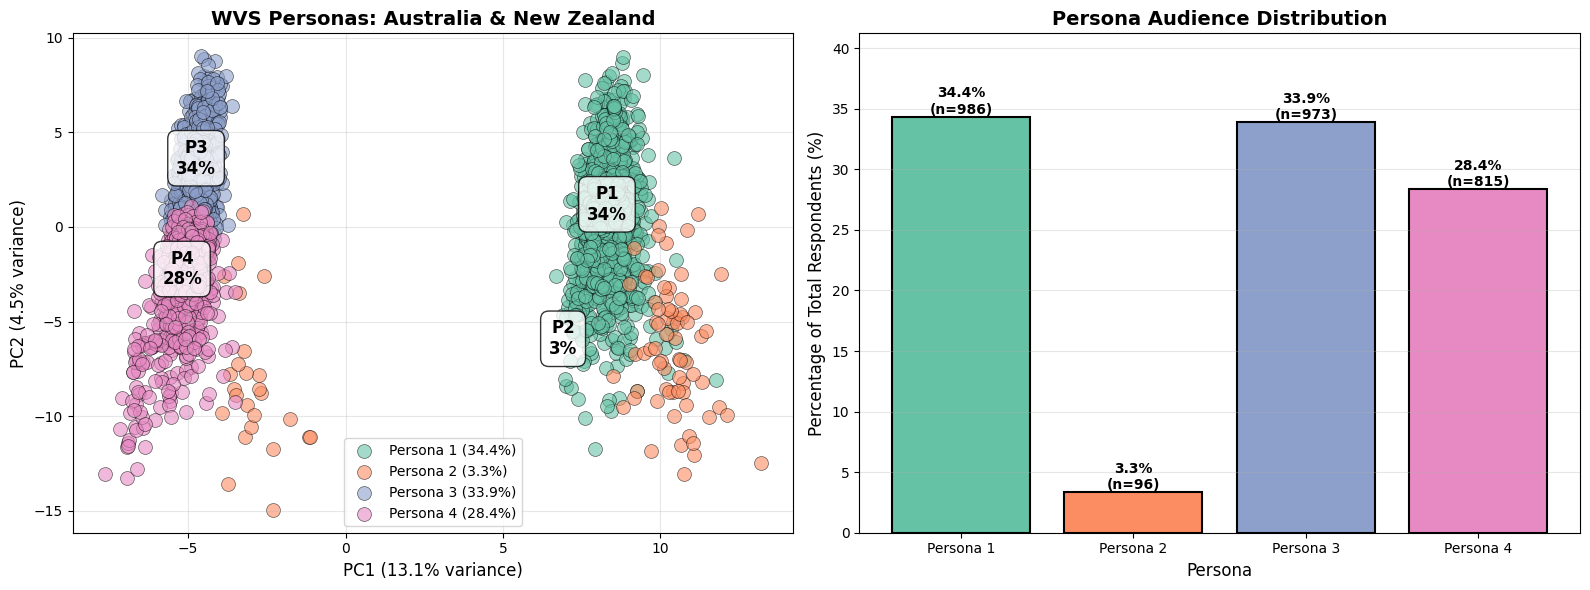


EXPORTING RESULTS

✓ Exported: persona_assignments.csv
  Contains 2870 respondents with persona assignments
✓ Exported: persona_summary.csv
  Contains high-level summary of 4 personas
✓ Exported: persona_profiles.json
  Contains detailed thematic profiles
✓ Exported: missing_data_report.csv
  Contains data quality assessment

EXPORT SUMMARY

Generated files:
  1. persona_assignments.csv      - Individual respondent assignments
  2. persona_summary.csv           - High-level persona overview
  3. persona_profiles.json         - Detailed thematic profiles
  4. missing_data_report.csv       - Data quality transparency
  5. optimal_clusters.png          - Clustering evaluation metrics
  6. personas_visualization.png    - Persona distribution visualization

PERSONA DEVELOPMENT COMPLETE

✓ Created 3 personas from 2870 respondents
✓ Used ~451 individual-level variables
✓ Grouped into 13 thematic categories

 Check output files:
   - persona_assignments.csv
   - persona_summary.csv
   - perso

In [ ]:
def main():
    """
    Main pipeline for data-driven persona development
    Following book principles for rigorous persona creation
    """
    print("="*70)
    print("WVS DATA-DRIVEN PERSONA DEVELOPMENT")
    print("Australia & New Zealand Dataset")
    print("Book-Compliant Implementation")
    print("="*70)

    # Initialize
    builder = WVSPersonaBuilder(
        data_file='WVS_Australia_NZ.xlsx',
        metadata_file='WVS_Metadata_v00.xlsx'
    )

    # Step 1: Load data and metadata
    builder.load_and_map_data()

    # Step 2: Build variable index with type classifications
    builder.build_variable_index()

    # Step 3: Select clustering features (removes 146 contextual variables)
    builder.select_clustering_features()

    # Step 4: Prepare data with type-appropriate encoding
    builder.prepare_for_clustering()

    # Step 5: Impute missing values with transparency reporting
    builder.impute_missing(strategy='knn', n_neighbors=5)

    # Step 6: Find optimal number of clusters (targeting 3-5 personas)
    # Step 6: Find optimal number of clusters (targeting 3-5 personas)
    optimal_k = builder.find_optimal_clusters(min_k=3, max_k=7)

    # Step 7: Override to k=5 for better persona balance
    # Note: k=3 was statistically optimal but resulted in poor distribution (3%/62%/34%)
    # and indistinct profiles. k=5 provides more balanced, actionable personas.
    print("\n" + "="*70)
    print("OVERRIDING OPTIMAL k FOR PRACTICAL BALANCE")
    print("="*70)
    print(f"\nStatistical optimal: k={optimal_k}")
    print(f"Selected for analysis: k=5")
    print(f"Reason: Better persona distribution and distinctiveness\n")

    builder.create_personas(n_clusters=4)

    # Step 8: Profile personas with thematic organization
    builder.profile_personas()

    # Step 9: Visualize personas with audience distribution
    builder.visualize_personas()

    # Step 10: Export all results
    builder.export_results()

    print("\n" + "="*70)
    print("PERSONA DEVELOPMENT COMPLETE")
    print("="*70)
    print(f"\n✓ Created {optimal_k} personas from {len(builder.raw_data)} respondents")
    print(f"✓ Used ~{len(builder.feature_columns)} individual-level variables")
    print(f"✓ Grouped into {len([k for k,v in builder.theme_groups.items() if len(v) > 0])} thematic categories")
    print("\n Check output files:")
    print("   - persona_assignments.csv")
    print("   - persona_summary.csv")
    print("   - persona_profiles.json")
    print("   - missing_data_report.csv")
    print("   - optimal_clusters.png")
    print("   - personas_visualization.png")
    print("\n💡 Next steps:")
    print("   1. Review persona_summary.csv for overview")
    print("   2. Examine optimal_clusters.png for clustering quality")
    print("   3. Check personas_visualization.png for distribution")
    print("   4. Use persona_profiles.json for detailed analysis")


if __name__ == "__main__":
    main()